# Packages

In [1]:
import sys
sys.path.append('/home/boscoll/github/CDKPredict/code')
from CDKPredict_scalable import CDKPredict_scalable
import matplotlib as mpl
import pickle
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from helper_functions import *

In [2]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}

# Data models

In [3]:
CDKPredictS_clin = CDKPredict_scalable.load_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinical_final.pkl')
CDKPredictS_clinicogenomic = CDKPredict_scalable.load_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/scalable_models/cdkpredict_scalable_clinicogenomic_final.pkl')

## MSK cohort
*needed to compute AUC[t] for estimating censoring*

In [4]:
project_path = Path('/home/boscoll/Projects/cdk_predict')
train_test_split = project_path / 'data/development_cohort/train_test_split/genomic_train_test_split_msk_final'
clinical_path = project_path / 'data/development_cohort/clinical/clinical_msk_final.csv'


with open(train_test_split, 'rb') as f:
    X_genomic_train, X_genomic_test, y_train, y_test = pickle.load(f)
y_msk = pd.concat([y_train, y_test])

## External multi-Institutional cohort

In [5]:
Ext_CDK = pd.read_csv('/home/boscoll/Projects/cdk_predict/data/Ext_CDK_final.csv', index_col = 0)
X_Ext_cdk = Ext_CDK.drop(columns=['Time', 'Event'])
y_Ext_cdk = Ext_CDK[['Time', 'Event']]

## IEO

In [6]:
with open('/home/boscoll/Projects/cdk_predict/data/ieo_cohort/ieo_cohort_final', 'rb') as f:
    ieo_clinical, ieo_clinicogenomic, y_ieo = pickle.load(f)

## Pool cohorts

In [7]:
#combined clinicogenomic cohort
X_combined_clinicogenomic = pd.concat([X_Ext_cdk, ieo_clinicogenomic])
y_combined_clinicogenomic = pd.concat([y_Ext_cdk, y_ieo]).query('index in @X_combined_clinicogenomic.index')

#combined clinical cohort
X_combined_clinical = pd.concat([X_Ext_cdk, ieo_clinical])
y_combined_clinical = pd.concat([y_Ext_cdk, y_ieo])

In [8]:
print(f'Nr. cases combined clinicogenomic cohort: {X_combined_clinicogenomic.shape[0]}')
print(f'Nr. cases combined clinical cohort: {X_combined_clinical.shape[0]}')

Nr. cases combined clinicogenomic cohort: 660
Nr. cases combined clinical cohort: 1019


## External validation CDKPredict-S clin

In [9]:
#predictions
Ext_combined_clinical = pd.concat([
    CDKPredictS_clin.predict(X_combined_clinical, classify =True, groups =3).to_frame('clinical_risk_group'),
    CDKPredictS_clin.predict(X_combined_clinical).to_frame('clinical_risk_score'), 
    y_combined_clinical
], axis = 1)
df_save = Ext_combined_clinical.copy()
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/clinical_scalable_model_external_validation.xlsx')

Dropping extra columns in test not seen in training, n. columns: 395
Activated the classify option, returning risk groups instead of continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 395
The option `classify` is set to False, returning continuous risk scores.


In [10]:
#reorder risk groups with low, intermediate and high
Ext_combined_clinical['clinical_risk_group'] = pd.Categorical(Ext_combined_clinical['clinical_risk_group'], categories=['low', 'intermediate', 'high'], ordered=True)
Ext_combined_clinical.sort_values('clinical_risk_group', inplace=True)

**Fig. 6f**

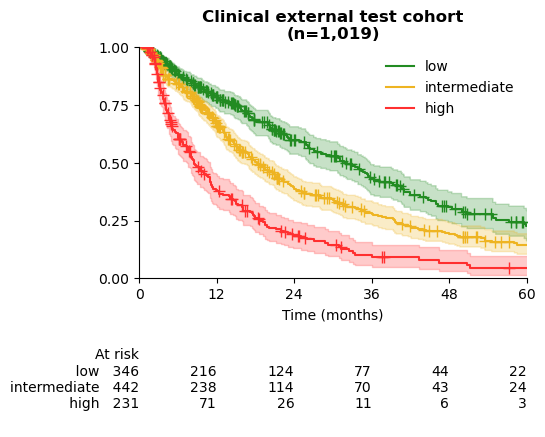

In [11]:
plot_kaplan_meier_risktable(Ext_combined_clinical, 'clinical_risk_group', colors = palette, conf_intervals = True, title = 'Clinical external test cohort\n(n=1,019)', upper_limit=60, figsize=(5,3), only_risk=True,
        #  save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/combined_external_cohort_km_clinical.pdf'
         )


**Fig. 6d**

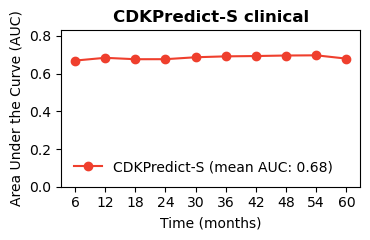

In [12]:
plot_time_dependent_auc_from_scores([Ext_combined_clinical['clinical_risk_score'].values], 
                                    ['CDKPredict-S'], 
                                    y_forSurv(y_msk), 
                                    y_forSurv(Ext_combined_clinical[['Event', 'Time']]), 
                                    grid = False,
                                    times=np.arange(6, 61, 6), 
                                    figsize=(3.8,2.5),
                                    ylim=(0, 0.83), 
                                    palette = {'CDKPredict-S': '#ef3f2d'},
                                    title = 'CDKPredict-S clinical', 
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/auc_scalable_clinical.pdf'
                                    )

**Extended Data Fig. 9c**

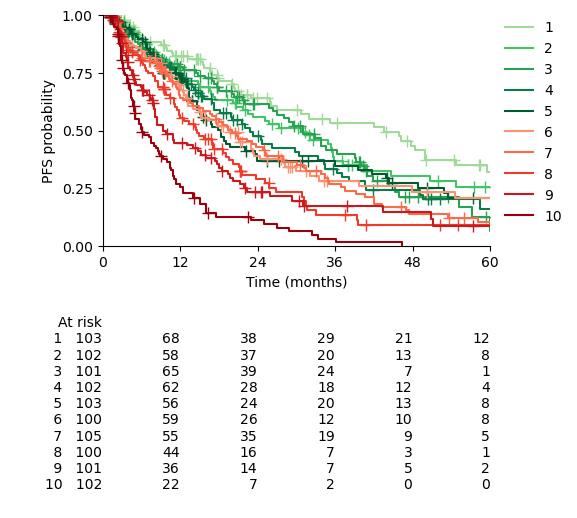

In [13]:
Ext_combined_clinical['risk_bin'] = pd.qcut(Ext_combined_clinical['clinical_risk_score'], q=10, labels=False)
Ext_combined_clinical['risk_bin'] = Ext_combined_clinical['risk_bin'] + 1
Ext_combined_clinical = Ext_combined_clinical.sort_values('risk_bin')
palette_km = {10:'#99000d', 9:'#cb181d', 8:'#ef3b2c', 7:'#fb6a4a', 6:'#fc9272', 5:'#005a32', 4:"#0B7C49", 3:"#2aa051", 2:"#44c366", 1:'#a1d99b'}
plot_kaplan_meier_risktable(Ext_combined_clinical, 'risk_bin', colors=palette_km, figsize=(5,3), conf_intervals=False, only_risk=True, legend_out=True, upper_limit=60,
                            ylabel = 'PFS probability',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_bin_clinical.pdf'
                            )


## External validation CDKPredict-S clinicogenomic

In [14]:
#predictions
Ext_combined_clinicogenomic = pd.concat([
    CDKPredictS_clinicogenomic.predict(X_combined_clinicogenomic, classify =True, groups =3).to_frame('clinicogenomic_risk_group'),
    CDKPredictS_clinicogenomic.predict(X_combined_clinicogenomic).to_frame('clinicogenomic_risk_score'), 
    y_combined_clinicogenomic
], axis = 1)
df_save = Ext_combined_clinicogenomic.copy()
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/clinicogenomic_scalable_model_external_validation.xlsx')

Dropping extra columns in test not seen in training, n. columns: 387
Activated the classify option, returning risk groups instead of continuous risk scores.
Dropping extra columns in test not seen in training, n. columns: 387
The option `classify` is set to False, returning continuous risk scores.


In [15]:
#reorder risk groups with low, intermediate and high
Ext_combined_clinicogenomic['clinicogenomic_risk_group'] = pd.Categorical(Ext_combined_clinicogenomic['clinicogenomic_risk_group'], categories=['low', 'intermediate', 'high'], ordered=True)
Ext_combined_clinicogenomic.sort_values('clinicogenomic_risk_group', inplace=True)

**Fig. 6g**

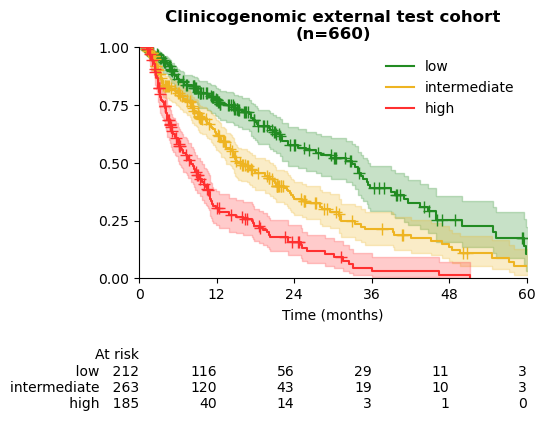

In [16]:
plot_kaplan_meier_risktable(Ext_combined_clinicogenomic, 'clinicogenomic_risk_group', colors = palette, conf_intervals = True, title = 'Clinicogenomic external test cohort\n(n=660)', upper_limit=60, figsize=(5,3), only_risk=True,
        #  save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/combined_external_cohort_km_clinicogenomic.pdf'
         )


**Fig. 6e**

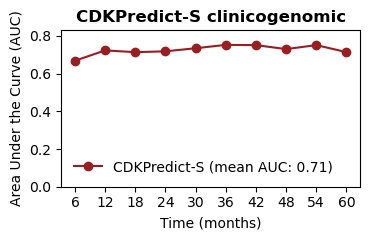

In [17]:
plot_time_dependent_auc_from_scores([Ext_combined_clinicogenomic['clinicogenomic_risk_score'].values], 
                                    ['CDKPredict-S'], 
                                    y_forSurv(y_msk), 
                                    y_forSurv(Ext_combined_clinicogenomic[['Event', 'Time']]), 
                                    grid = False,
                                    times=np.arange(6, 61, 6), 
                                    figsize=(3.8,2.5),
                                    ylim=(0, 0.83), 
                                    palette = {'CDKPredict-S': '#9a1d21'},
                                    title = 'CDKPredict-S clinicogenomic', 
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/auc_scalable_clinicogenomic.pdf'
                                    )

**Extended Data Fig. 9d**

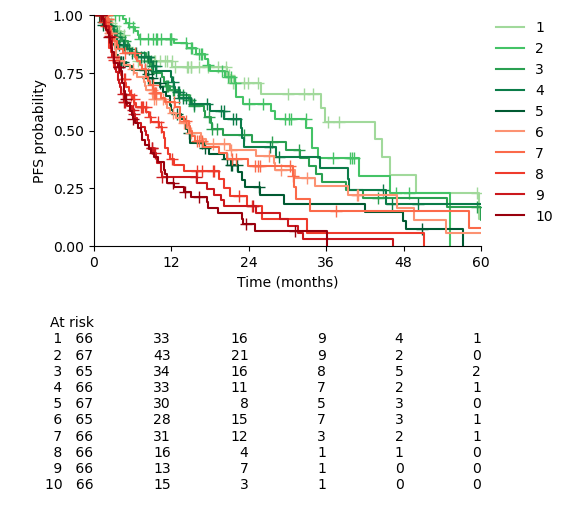

In [18]:
Ext_combined_clinicogenomic['risk_bin'] = pd.qcut(Ext_combined_clinicogenomic['clinicogenomic_risk_score'], q=10, labels=False)
Ext_combined_clinicogenomic['risk_bin'] = Ext_combined_clinicogenomic['risk_bin'] + 1
Ext_combined_clinicogenomic = Ext_combined_clinicogenomic.sort_values('risk_bin')
palette_km = {10:'#99000d', 9:'#cb181d', 8:'#ef3b2c', 7:'#fb6a4a', 6:'#fc9272', 5:'#005a32', 4:"#0B7C49", 3:"#2aa051", 2:"#44c366", 1:'#a1d99b'}
plot_kaplan_meier_risktable(Ext_combined_clinicogenomic, 'risk_bin', colors=palette_km, figsize=(5,3), conf_intervals=False, only_risk=True, legend_out=True, upper_limit=60,
                            ylabel = 'PFS probability',
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/minimal_model/risk_bin_clinicogenomic.pdf'
                            )
